<a href="https://colab.research.google.com/github/patelmegh1784/ShadowFox/blob/main/Intermediate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving delhiaqi.csv to delhiaqi.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# 1. Load and Prepare the Data
# Set seaborn style
sns.set(style="whitegrid")

# Load dataset
df = pd.read_csv("delhiaqi.csv")

# Convert 'date' to datetime format
df['date'] = pd.to_datetime(df['date'])

# Extract month and assign seasons
df['month'] = df['date'].dt.month
df['season'] = df['month'].apply(lambda m:
    'Winter' if m in [12, 1, 2] else
    'Summer' if m in [3, 4, 5] else
    'Monsoon' if m in [6, 7, 8] else
    'Post-Monsoon'
)

# List of pollutants to analyze
pollutants = ['pm2_5', 'pm10', 'co', 'no', 'no2', 'o3', 'so2', 'nh3']


<ipython-input-9-eae469b913ec>:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.set_index('date')[pollutant].resample('M').mean().plot(label=pollutant)
/usr/local/lib/python3.11/dist-packages/pandas/plotting/_matplotlib/core.py:1561: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)
<ipython-input-9-eae469b913ec>:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.set_index('date')[pollutant].resample('M').mean().plot(label=pollutant)
/usr/local/lib/python3.11/dist-packages/pandas/plotting/_matplotlib/core.py:1561: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)
<ipython-input-9-eae469b913ec>:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instea

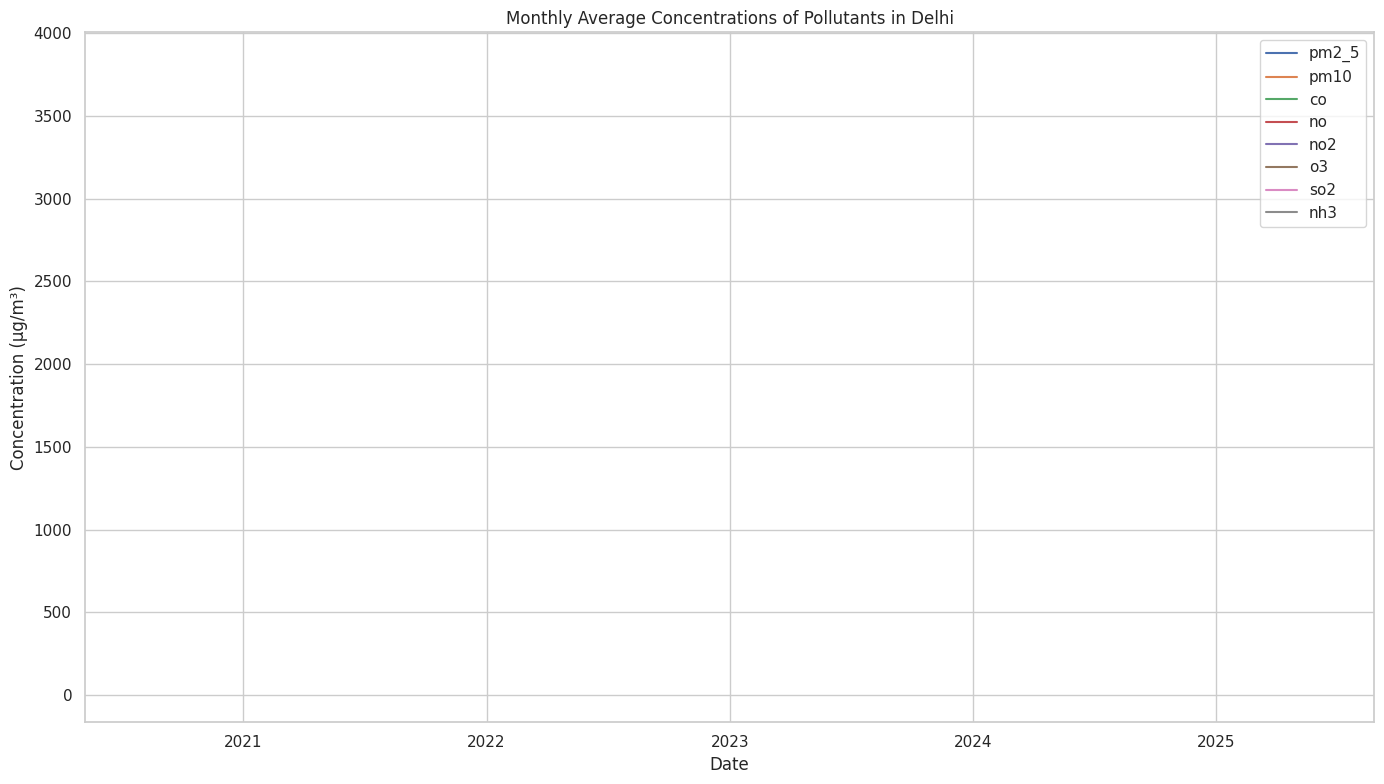

In [ ]:
#2. Chart: Monthly Trends of All Pollutants
plt.figure(figsize=(14, 8))
for pollutant in pollutants:
    df.set_index('date')[pollutant].resample('M').mean().plot(label=pollutant)

plt.title('Monthly Average Concentrations of Pollutants in Delhi')
plt.xlabel('Date')
plt.ylabel('Concentration (μg/m³)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


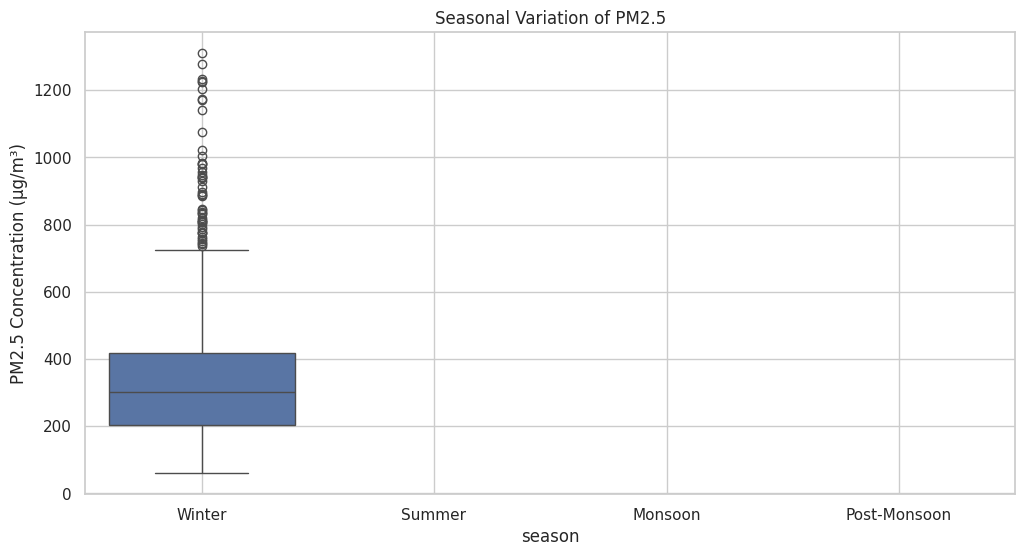

In [ ]:
#3. Chart: Seasonal Variation of PM2.5
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='season', y='pm2_5', order=['Winter', 'Summer', 'Monsoon', 'Post-Monsoon'])
plt.title('Seasonal Variation of PM2.5')
plt.ylabel('PM2.5 Concentration (μg/m³)')
plt.grid(True)
plt.show()


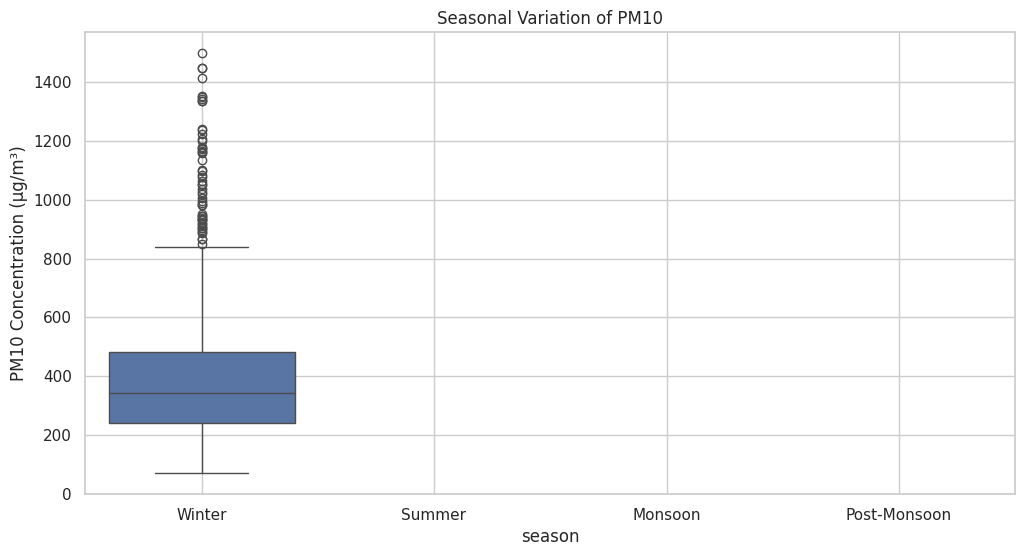

In [ ]:
#4. Chart: Seasonal Variation of PM10
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='season', y='pm10', order=['Winter', 'Summer', 'Monsoon', 'Post-Monsoon'])
plt.title('Seasonal Variation of PM10')
plt.ylabel('PM10 Concentration (μg/m³)')
plt.grid(True)
plt.show()


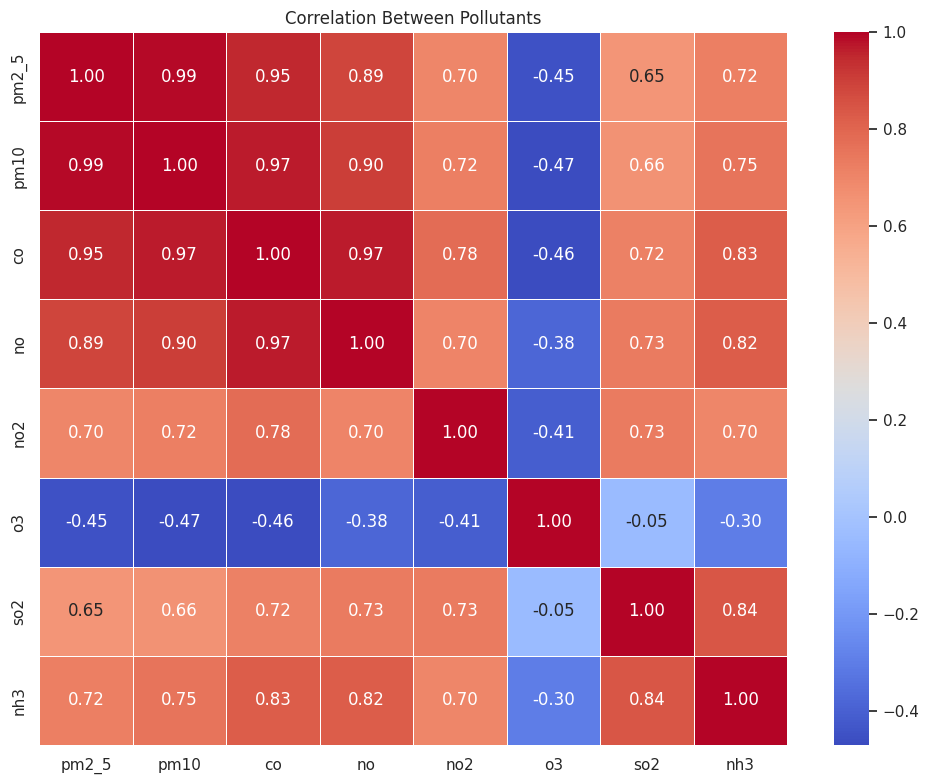

In [ ]:
#5. Chart: Correlation Heatmap of Pollutants
plt.figure(figsize=(10, 8))
corr = df[pollutants].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Between Pollutants')
plt.tight_layout()
plt.show()


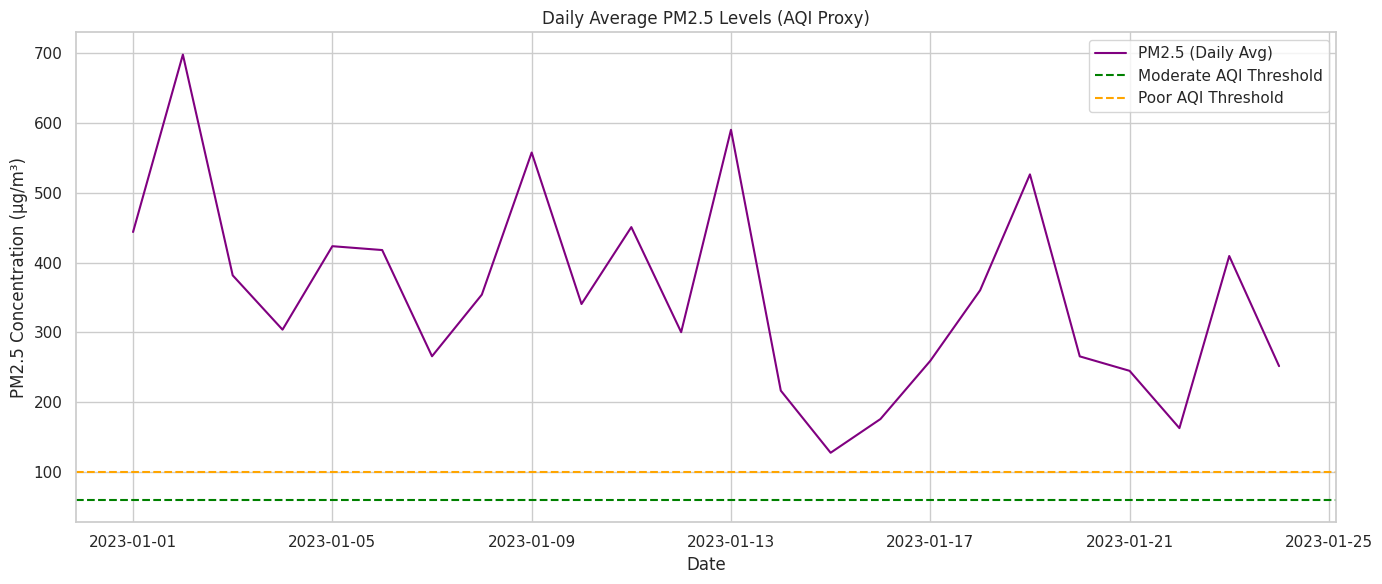

In [ ]:
#6. Chart: Daily PM2.5 Trend (AQI Proxy)
daily_avg = df.set_index('date')[pollutants].resample('D').mean()

plt.figure(figsize=(14, 6))
plt.plot(daily_avg.index, daily_avg['pm2_5'], label='PM2.5 (Daily Avg)', color='purple')
plt.axhline(60, color='green', linestyle='--', label='Moderate AQI Threshold')
plt.axhline(100, color='orange', linestyle='--', label='Poor AQI Threshold')
plt.title('Daily Average PM2.5 Levels (AQI Proxy)')
plt.xlabel('Date')
plt.ylabel('PM2.5 Concentration (μg/m³)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
